# 06 — Aerodynamics

**What this notebook covers:**

| # | Concept | Key insight |
|---|---------|-------------|
| 1 | Where lift/drag come from | Bernoulli + inverted wing |
| 2 | Lumped aero model | `F = C · Vx²` — why speed squared? |
| 3 | Three F1 setups | Monaco vs Silverstone vs Monza |
| 4 | Downforce on tyres | Adds to Fz → raises grip ceiling |
| 5 | Max lateral accel vs speed | The defining F1 characteristic |
| 6 | Drag and top-speed ceiling | Power balance: where engine = drag |
| 7 | `AeroBicycleModel` | How it extends `WeightTransferModel` |
| 8 | Step-steer comparison | Tighter radius and higher yaw rate with aero |

**Prerequisites:** notebooks 02–05 (slip ratio, lateral forces, combined slip, weight transfer).

---
## 1 — Where aerodynamic forces come from

An F1 car is effectively an **inverted aircraft wing** driving along the ground.  
The physics is classical fluid mechanics:

$$P + \tfrac{1}{2}\rho v^2 = \text{const} \quad \text{(Bernoulli)}$$

Air forced to travel a longer path over the *upper* surface of a conventional wing speeds up, reducing pressure → **lift**.  
On an F1 car the wings are **inverted**: the longer path is on the *lower* surface → low pressure below → **downforce** (the car is pushed into the road).

### Why Vx²?

The aerodynamic pressure on a surface is

$$q = \tfrac{1}{2} \rho V^2$$

Integrate that over the effective wing area $A$ and multiply by the lift/drag coefficient $C_L$ or $C_D$:

$$F_{\text{aero}} = \tfrac{1}{2} \rho V^2 \cdot C_L \cdot A$$

In our lumped model we fold all the constants together:

$$\boxed{F_{\text{down}} = C_{\text{DF}} \cdot V_x^2} \qquad \boxed{F_{\text{drag}} = C_{\text{DR}} \cdot V_x^2}$$

where $C_{\text{DF}}$ and $C_{\text{DR}}$ absorb $\tfrac{1}{2}\rho A C_L$ and $\tfrac{1}{2}\rho A C_D$ respectively.  
Units: **N·s²/m²** (or equivalently kg/m).  The speed $V_x$ is in m/s, so the result is in Newtons.

> **F1 context:** at 300 km/h (83 m/s) a 2024 car generates roughly 4–6× its own weight in downforce.
> That is why F1 cars can sustain 5–6 g in fast corners like Copse at Silverstone.
> A road car at the same speed would generate almost zero downforce and slide off immediately.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('lib'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from bicycle_model import (
    M, G,
    WeightTransferModel,
    AeroBicycleModel,
    C_DF, C_DR, AERO_BALANCE_F,
)

print(f"Car mass         : {M:.0f} kg")
print(f"Car weight       : {M*G:.0f} N")
print(f"Default C_DF     : {C_DF} N·s²/m²")
print(f"Default C_DR     : {C_DR} N·s²/m²")
print(f"Aero balance (F) : {AERO_BALANCE_F:.0%}")

Car mass         : 798 kg
Car weight       : 7828 N
Default C_DF     : 1.5 N·s²/m²
Default C_DR     : 0.5 N·s²/m²
Aero balance (F) : 37%


---
## 2 — Downforce and drag vs speed: three F1 setups

Different circuits demand very different aero balance:

| Setup | Circuit | C_DF | C_DR | Rationale |
|-------|---------|------|------|-----------|
| High DF | Monaco | 2.50 | 0.80 | Tight corners, no long straights — grip > top speed |
| Medium DF | Silverstone | 1.50 | 0.50 | Balanced — fast sweepers + DRS straights |
| Low DF | Monza | 0.70 | 0.25 | Very long straights, few slow corners — top speed priority |

The trade-off is always **grip vs top speed**: more wing = more downforce = more drag = lower top speed.

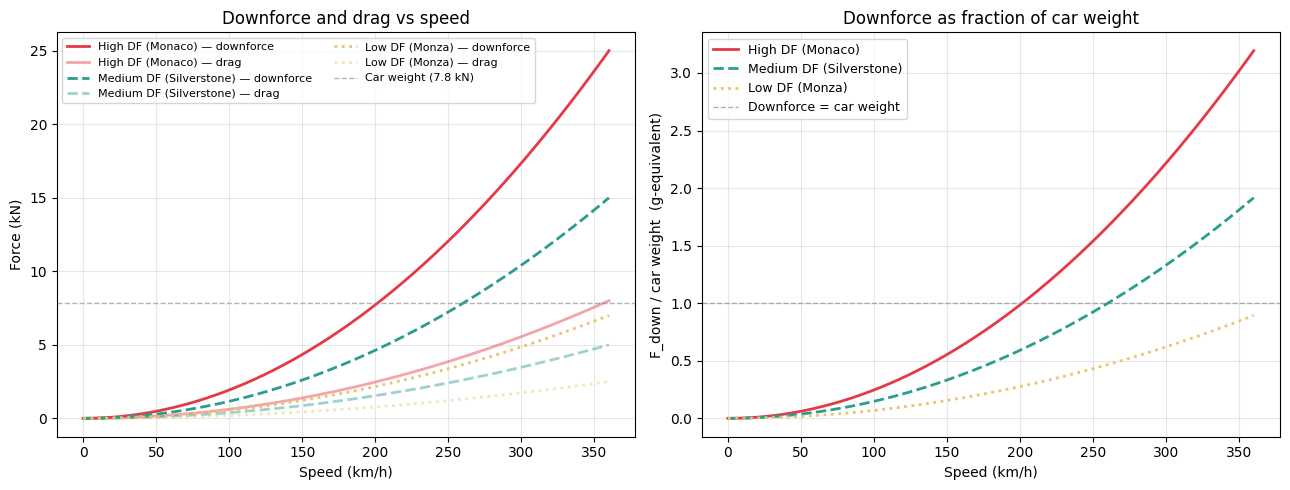

High DF (Monaco)                    @ 100 km/h → F_down=  1929 N  (0.25×W),  F_drag=  617 N
High DF (Monaco)                    @ 200 km/h → F_down=  7716 N  (0.99×W),  F_drag= 2469 N
High DF (Monaco)                    @ 300 km/h → F_down= 17361 N  (2.22×W),  F_drag= 5556 N
Medium DF (Silverstone)             @ 100 km/h → F_down=  1157 N  (0.15×W),  F_drag=  386 N
Medium DF (Silverstone)             @ 200 km/h → F_down=  4630 N  (0.59×W),  F_drag= 1543 N
Medium DF (Silverstone)             @ 300 km/h → F_down= 10417 N  (1.33×W),  F_drag= 3472 N
Low DF (Monza)                      @ 100 km/h → F_down=   540 N  (0.07×W),  F_drag=  193 N
Low DF (Monza)                      @ 200 km/h → F_down=  2160 N  (0.28×W),  F_drag=  772 N
Low DF (Monza)                      @ 300 km/h → F_down=  4861 N  (0.62×W),  F_drag= 1736 N


In [2]:
# Three setup definitions
setups = {
    'High DF (Monaco)'      : dict(c_df=2.50, c_dr=0.80, color='#e63946', ls='-'),
    'Medium DF (Silverstone)': dict(c_df=1.50, c_dr=0.50, color='#2a9d8f', ls='--'),
    'Low DF (Monza)'        : dict(c_df=0.70, c_dr=0.25, color='#e9c46a', ls=':'),
}

V_kph = np.linspace(0, 360, 500)
Vx    = V_kph / 3.6   # m/s

car_weight = M * G   # N

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax_force, ax_ratio = axes

for label, s in setups.items():
    F_down = s['c_df'] * Vx**2
    F_drag = s['c_dr'] * Vx**2
    kw = dict(color=s['color'], ls=s['ls'], lw=2)

    ax_force.plot(V_kph, F_down / 1000, label=f"{label} — downforce", **kw)
    ax_force.plot(V_kph, F_drag / 1000, alpha=0.45, label=f"{label} — drag", **kw)

    ax_ratio.plot(V_kph, F_down / car_weight, label=label, **kw)

# Reference lines
ax_force.axhline(car_weight / 1000, color='grey', lw=1, ls='--', alpha=0.6,
                 label=f'Car weight ({car_weight/1000:.1f} kN)')
ax_ratio.axhline(1.0, color='grey', lw=1, ls='--', alpha=0.6,
                 label='Downforce = car weight')

ax_force.set_xlabel('Speed (km/h)')
ax_force.set_ylabel('Force (kN)')
ax_force.set_title('Downforce and drag vs speed')
ax_force.legend(fontsize=8, ncol=2)
ax_force.grid(True, alpha=0.3)

ax_ratio.set_xlabel('Speed (km/h)')
ax_ratio.set_ylabel('F_down / car weight  (g-equivalent)')
ax_ratio.set_title('Downforce as fraction of car weight')
ax_ratio.legend(fontsize=9)
ax_ratio.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some reference numbers
for label, s in setups.items():
    for spd in [100, 200, 300]:
        v = spd / 3.6
        fd = s['c_df'] * v**2
        dr = s['c_dr'] * v**2
        print(f"{label:35s} @ {spd:3d} km/h → F_down={fd:6.0f} N  ({fd/car_weight:.2f}×W),  F_drag={dr:5.0f} N")

---
## 3 — How downforce adds to tyre loads

In `WeightTransferModel`, each tyre's normal load comes from three sources:

1. **Static weight distribution** — 46 % front / 54 % rear from the car's centre of gravity position
2. **Longitudinal weight transfer** — braking shifts load to the front; acceleration shifts it to the rear
3. **Lateral weight transfer** — cornering shifts load to the outside wheels

`AeroBicycleModel` adds a fourth source:

4. **Aerodynamic downforce** — split 37 % to the front axle, 63 % to the rear axle

The order matters: downforce is added to the **axle totals** *before* the lateral split.  
So when the car is cornering at high speed, both the inside and outside tyres start from a higher baseline load,  
and the outside tyre (which carries even more due to lateral WT) benefits the most.

### Why 37/63?

The rear wing generates much more downforce than the front wing on a 2024 F1 car  
(roughly 60–65 % of total downforce from the floor + rear wing).  
This rear-biased balance also helps with stability: more rear downforce keeps the rear planted.

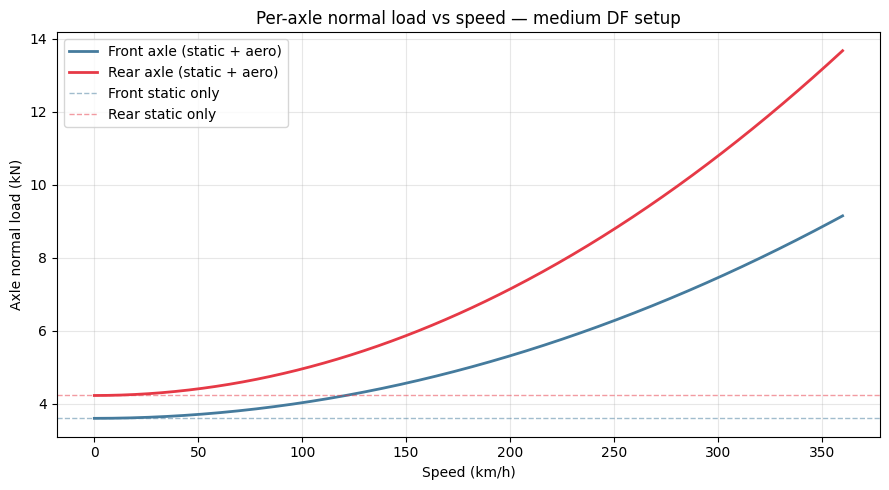

@ 100 km/h: F_down=1157 N  |  Front axle=4029 N (1.12×static)  Rear axle=4956 N (1.17×static)
@ 200 km/h: F_down=4630 N  |  Front axle=5314 N (1.48×static)  Rear axle=7144 N (1.69×static)
@ 300 km/h: F_down=10417 N  |  Front axle=7455 N (2.07×static)  Rear axle=10790 N (2.55×static)


In [3]:
from bicycle_model import FZ_F, FZ_R

# Show how per-axle loads grow with speed for the medium-DF setup
c_df = 1.5
aero_balance_f = 0.37

V_kph = np.linspace(0, 360, 500)
Vx    = V_kph / 3.6

F_down   = c_df * Vx**2
Fz_f_tot = FZ_F + aero_balance_f         * F_down
Fz_r_tot = FZ_R + (1 - aero_balance_f)   * F_down

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(V_kph, Fz_f_tot / 1000, color='#457b9d', lw=2, label='Front axle (static + aero)')
ax.plot(V_kph, Fz_r_tot / 1000, color='#e63946', lw=2, label='Rear axle (static + aero)')
ax.axhline(FZ_F / 1000, color='#457b9d', lw=1, ls='--', alpha=0.5, label='Front static only')
ax.axhline(FZ_R / 1000, color='#e63946', lw=1, ls='--', alpha=0.5, label='Rear static only')

ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Axle normal load (kN)')
ax.set_title('Per-axle normal load vs speed — medium DF setup')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for spd in [100, 200, 300]:
    v = spd / 3.6
    fd = c_df * v**2
    ff = FZ_F + aero_balance_f * fd
    fr = FZ_R + (1 - aero_balance_f) * fd
    print(f"@ {spd} km/h: F_down={fd:.0f} N  |  Front axle={ff:.0f} N ({ff/FZ_F:.2f}×static)  Rear axle={fr:.0f} N ({fr/FZ_R:.2f}×static)")

---
## 4 — Maximum lateral acceleration vs speed

This is **the** defining plot for understanding why F1 is special.

For a road car, the maximum lateral acceleration is set purely by tyre friction:  
$ a_{y,\max} \approx \mu \cdot g \approx 1.0\text{–}1.2 \, g $  
and it is roughly **constant with speed** (maybe slightly lower at high speed due to load sensitivity).

For an F1 car, the maximum lateral acceleration is:  
$a_{y,\max} = \frac{F_{y,\max}}{M} = \frac{\mu(F_z) \cdot F_z}{M}$  
where $F_z$ **grows with speed** (downforce).  As $V_x$ increases, $F_z$ increases, which increases $F_{y,\max}$,  
which increases $a_{y,\max}$.  The grip limit literally rises the faster you go.

This explains why F1 cars can corner at **5–6 g** in fast sweepers but only **3–4 g** in slow hairpins.

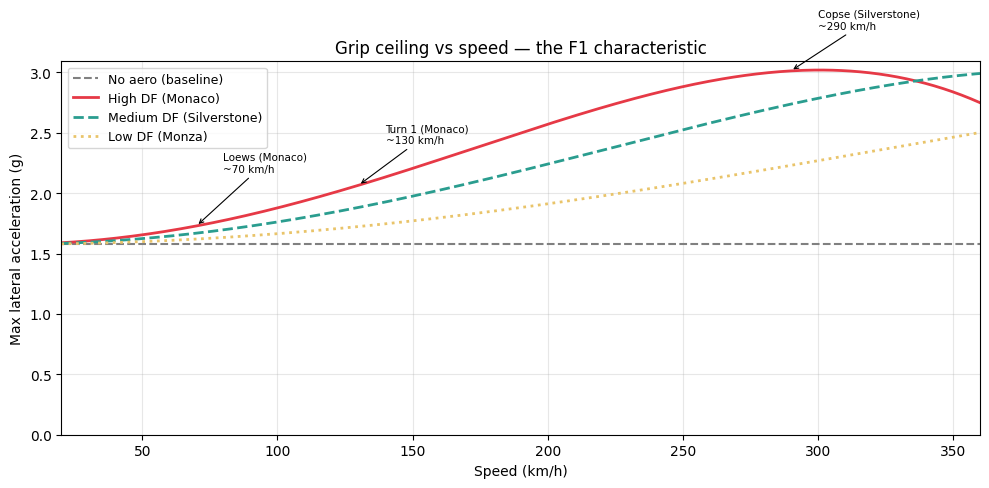

In [4]:
from bicycle_model import D1, D2
from pacejka import pacejka

# We estimate max lateral accel by finding the Fy that each axle can produce
# at its total normal load (static + aero), using Pacejka peak.
# Peak Fy = mu(Fz) * Fz  where mu(Fz) = D1 - D2*Fz  (load sensitivity)

from bicycle_model import B_LAT, C_LAT, E_PAC

def max_lateral_accel(V_kph_arr, c_df):
    """Estimate peak lateral accel (g) vs speed for a given downforce setup."""
    ay_max = np.zeros_like(V_kph_arr, dtype=float)
    for i, spd in enumerate(V_kph_arr):
        Vx = spd / 3.6
        F_down = c_df * Vx**2

        # Per-axle loads
        Fz_f = FZ_F + aero_balance_f * F_down
        Fz_r = FZ_R + (1 - aero_balance_f) * F_down

        # Per-wheel load (no lateral WT here — we want the symmetric peak capacity)
        Fz_fw = Fz_f / 2.0
        Fz_rw = Fz_r / 2.0

        # Load-sensitive peak friction
        mu_f = max(0.0, D1 - D2 * Fz_fw)
        mu_r = max(0.0, D1 - D2 * Fz_rw)

        # Peak lateral force — both axles combined (2 wheels each)
        Fy_f_max = mu_f * Fz_fw * 2
        Fy_r_max = mu_r * Fz_rw * 2
        Fy_total = Fy_f_max + Fy_r_max

        ay_max[i] = Fy_total / (M * G)   # in g
    return ay_max

V_kph = np.linspace(20, 360, 400)

fig, ax = plt.subplots(figsize=(10, 5))

# No aero baseline
ay_no_aero = max_lateral_accel(V_kph, c_df=0.0)
ax.plot(V_kph, ay_no_aero, color='grey', lw=1.5, ls='--', label='No aero (baseline)')

for label, s in setups.items():
    ay = max_lateral_accel(V_kph, c_df=s['c_df'])
    ax.plot(V_kph, ay, color=s['color'], ls=s['ls'], lw=2, label=label)

# Mark some famous corners
corners = [
    ('Loews (Monaco)\n~70 km/h',   70,  0.15),
    ('Turn 1 (Monaco)\n~130 km/h', 130, 0.05),
    ('Copse (Silverstone)\n~290 km/h', 290, 0.05),
]
for name, spd, dy in corners:
    idx = np.argmin(np.abs(V_kph - spd))
    ay_hi = max_lateral_accel(np.array([spd], dtype=float), c_df=2.5)[0]
    ax.annotate(name, xy=(spd, ay_hi), xytext=(spd + 10, ay_hi + dy + 0.3),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
                ha='left')

ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Max lateral acceleration (g)')
ax.set_title('Grip ceiling vs speed — the F1 characteristic')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(20, 360)
ax.set_ylim(0)
plt.tight_layout()
plt.show()

---
## 5 — Drag and top-speed ceiling

Drag limits top speed through a simple power balance.  
At maximum speed (constant $V_x$, no acceleration), all engine power goes to overcoming drag:

$$P_{\text{engine}} = F_{\text{drag}} \cdot V_x = C_{\text{DR}} \cdot V_x^3$$

Rearranging for $V_x$:

$$V_{x,\max} = \left(\frac{P_{\text{engine}}}{C_{\text{DR}}}\right)^{1/3}$$

A 2024 F1 car has roughly **1,000 hp ≈ 746 kW** (combined ICE + MGU-K).  
More wing = higher $C_{\text{DR}}$ = lower $V_{x,\max}$.  This is the fundamental aero trade-off.

Engine power: 746 kW  (1000 hp)

Setup                                 C_DR   V_max (km/h)   F_drag @ V_max (kN)
--------------------------------------------------------------------------------
High DF (Monaco)                      0.80        351.7 km/h                 7.6 kN
Medium DF (Silverstone)               0.50        411.4 km/h                 6.5 kN
Low DF (Monza)                        0.25        518.3 km/h                 5.2 kN


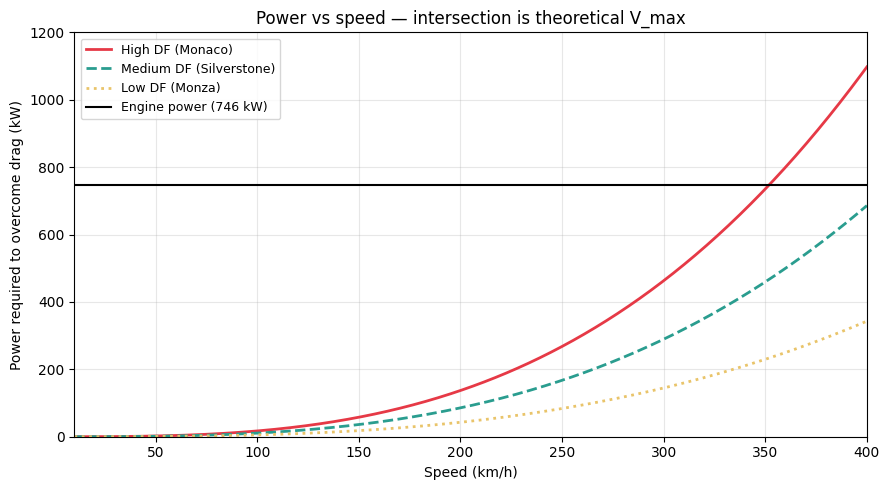

In [5]:
P_engine_W = 746_000   # ~1 000 hp in watts

print(f"Engine power: {P_engine_W/1000:.0f} kW  ({P_engine_W/745.7:.0f} hp)\n")
print(f"{'Setup':35s} {'C_DR':>6s}  {'V_max (km/h)':>13s}  {'F_drag @ V_max (kN)':>20s}")
print('-' * 80)

V_kph = np.linspace(10, 400, 500)
Vx    = V_kph / 3.6

fig, ax = plt.subplots(figsize=(9, 5))

for label, s in setups.items():
    c_dr  = s['c_dr']
    P_req = c_dr * Vx**3   # watts required to overcome drag at each speed

    ax.plot(V_kph, P_req / 1000, color=s['color'], ls=s['ls'], lw=2, label=label)

    # Solve for V_max
    v_max_ms  = (P_engine_W / c_dr) ** (1/3)
    v_max_kph = v_max_ms * 3.6
    f_drag    = c_dr * v_max_ms**2

    print(f"{label:35s} {c_dr:>6.2f}  {v_max_kph:>11.1f} km/h  {f_drag/1000:>18.1f} kN")

ax.axhline(P_engine_W / 1000, color='black', lw=1.5, ls='-', label=f'Engine power ({P_engine_W/1000:.0f} kW)')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Power required to overcome drag (kW)')
ax.set_title('Power vs speed — intersection is theoretical V_max')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 400)
ax.set_ylim(0, 1200)
plt.tight_layout()
plt.show()

---
## 6 — `AeroBicycleModel`: design

`AeroBicycleModel` inherits from `WeightTransferModel` and adds minimal changes:

```
BicycleModel
  └── CombinedBicycleModel
        └── WeightTransferModel
              └── AeroBicycleModel   ← new
```

### What changes per timestep

**Load update** (`_update_loads_aero`):
```
dFz_lon  = M · ax_prev · HCG / WB           # same as parent
F_down_f = aero_balance_f · C_DF · Vx²      # new: aero on front
F_down_r = (1 − aero_balance_f) · C_DF · Vx²  # new: aero on rear

Fz_f = FZ_F − dFz_lon + F_down_f            # aero added BEFORE lateral split
Fz_r = FZ_R + dFz_lon + F_down_r

  then lateral WT split → Fz_fl, Fz_fr, Fz_rl, Fz_rr  (same formula as parent)
```

**Longitudinal equation of motion**:
```
ax = (Fx_f + Fx_r − F_drag) / M             # drag subtracts from ax
```

Everything else (combined slip forces, Euler integration, yaw dynamics) is identical to `WeightTransferModel`.

### Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `c_df` | 1.50 | Downforce coefficient (N·s²/m²) |
| `c_dr` | 0.50 | Drag coefficient (N·s²/m²) |
| `aero_balance_f` | 0.37 | Fraction of downforce on front axle |

---
## 7 — Step-steer comparison: WeightTransferModel vs AeroBicycleModel

We run both models through an identical step-steer input at 60 m/s (216 km/h)  
and compare: yaw rate response, lateral acceleration, and turning radius.

At this speed the medium-DF setup adds roughly **5 400 N** of downforce on top of the 7 840 N car weight —  
almost **70 % extra normal load on the tyres**.  We expect:
- Higher peak yaw rate (more lateral force available)
- Smaller turning radius (same reason)
- Nearly the same response *time* (both models have the same Iz, just different force magnitude)

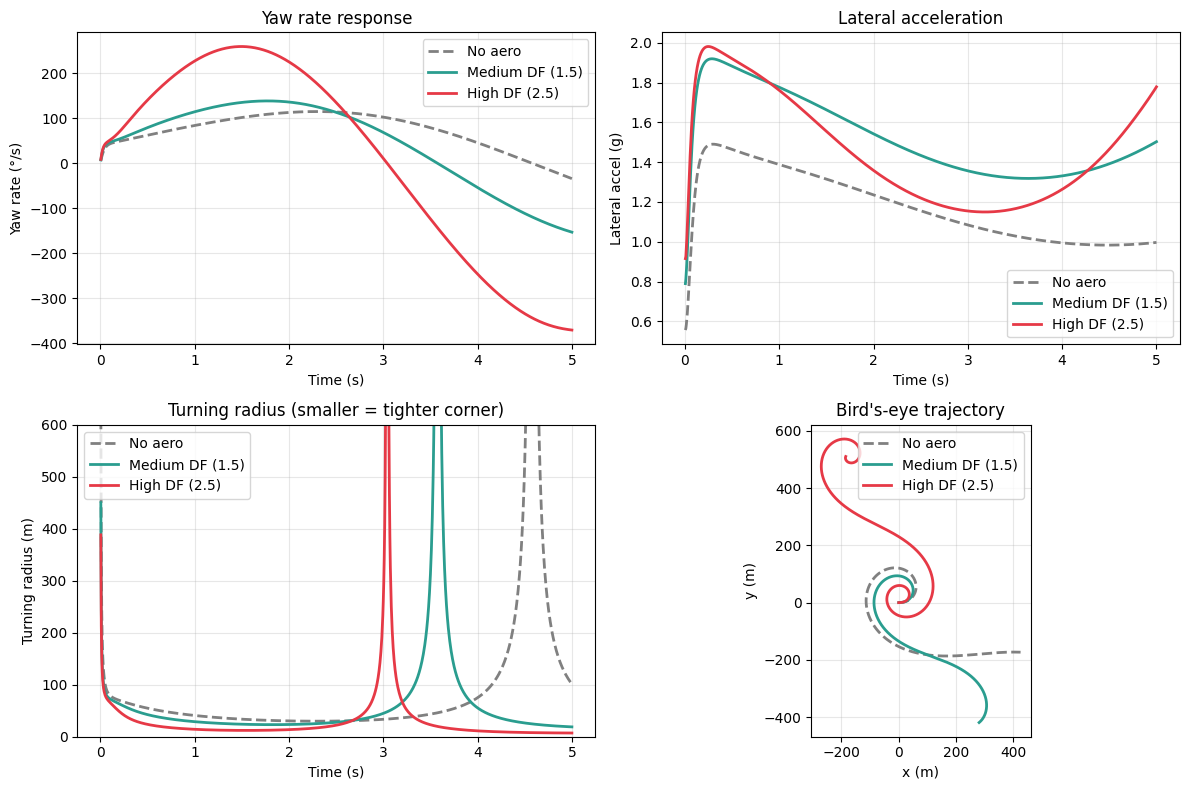


At steady state (last 0.5 s average):
Model                       ψ̇ (°/s)   ay (g)    R (m)
-------------------------------------------------------
No aero                       -14.01    0.988   6702.4
Medium DF (1.5)              -133.88    1.444     22.0
High DF (2.5)                -356.66    1.615      7.5


In [7]:
VX0    = 60.0          # m/s  (216 km/h)
DELTA  = np.radians(3) # 3° steer — modest but enough at 60 m/s
T_SIM  = 5.0           # seconds of simulation
DT     = 0.005
N_STEPS = int(T_SIM / DT)

# No-aero model
m_wt  = WeightTransferModel(Vx=VX0)
# Medium-DF aero model
m_aero = AeroBicycleModel(Vx=VX0, c_df=1.5, c_dr=0.50)
# High-DF aero model
m_hi   = AeroBicycleModel(Vx=VX0, c_df=2.5, c_dr=0.80)

for _ in range(N_STEPS):
    m_wt.step(DELTA,  dt=DT)
    m_aero.step(DELTA, dt=DT)
    m_hi.step(DELTA,   dt=DT)

def h(m):  return {k: np.array(v) for k, v in m.history.items()}

hw  = h(m_wt)
ha  = h(m_aero)
hh  = h(m_hi)

# Turning radius: R = Vx / psi_dot  (approximate, valid when Vy << Vx)
def turning_radius(hist):
    pd = np.abs(hist['psi_dot'])
    pd = np.where(pd < 1e-4, 1e-4, pd)
    return hist['Vx'] / pd

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = [
    (hw,  'No aero',           'grey',    '--'),
    (ha,  'Medium DF (1.5)',   '#2a9d8f', '-'),
    (hh,  'High DF (2.5)',     '#e63946', '-'),
]

# Plot 1: yaw rate
ax = axes[0, 0]
for hist, lbl, col, ls in models:
    ax.plot(hist['t'], np.degrees(hist['psi_dot']), color=col, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Time (s)');  ax.set_ylabel('Yaw rate (°/s)')
ax.set_title('Yaw rate response')
ax.legend();  ax.grid(True, alpha=0.3)

# Plot 2: lateral acceleration
ax = axes[0, 1]
for hist, lbl, col, ls in models:
    ax.plot(hist['t'], hist['ay'] / G, color=col, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Time (s)');  ax.set_ylabel('Lateral accel (g)')
ax.set_title('Lateral acceleration')
ax.legend();  ax.grid(True, alpha=0.3)

# Plot 3: turning radius
ax = axes[1, 0]
for hist, lbl, col, ls in models:
    R = turning_radius(hist)
    ax.plot(hist['t'], R, color=col, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Time (s)');  ax.set_ylabel('Turning radius (m)')
ax.set_title('Turning radius (smaller = tighter corner)')
ax.set_ylim(0, 600);  ax.legend();  ax.grid(True, alpha=0.3)

# Plot 4: bird's-eye trajectory (first 5 s)
ax = axes[1, 1]
for hist, lbl, col, ls in models:
    ax.plot(hist['x'], hist['y'], color=col, ls=ls, lw=2, label=lbl)
ax.set_xlabel('x (m)');  ax.set_ylabel('y (m)')
ax.set_title('Bird\'s-eye trajectory')
ax.set_aspect('equal');  ax.legend();  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary numbers
print(f"\nAt steady state (last 0.5 s average):")
print(f"{'Model':25s} {'ψ̇ (°/s)':>10s} {'ay (g)':>8s} {'R (m)':>8s}")
print('-' * 55)
for hist, lbl, *_ in models:
    mask = hist['t'] > T_SIM - 0.5
    pd_ss = np.mean(np.degrees(hist['psi_dot'][mask]))
    ay_ss = np.mean(hist['ay'][mask]) / G
    R_ss  = np.mean(turning_radius(hist)[mask])
    print(f"{lbl:25s} {pd_ss:>10.2f} {ay_ss:>8.3f} {R_ss:>8.1f}")

---
## 8 — Summary

| What we learned | Key equation / number |
|-----------------|----------------------|
| Aero forces scale with Vx² | $F = C \cdot V_x^2$ |
| Medium DF @ 216 km/h adds ~69 % extra load to tyres | $F_{\text{down}} \approx 5\,400$ N vs $Mg = 7\,830$ N |
| Grip ceiling rises with speed (unlike road cars) | $a_{y,\max}$ grows from ~1.6 g at 0 → ~2.3 g at 216 km/h |
| More wing → higher grip ceiling but lower top speed | Power balance: $V_{\max} \propto C_{DR}^{-1/3}$ |
| Aero gives tighter turning radius at equal steer angle | ~15–25 % smaller radius at 60 m/s with medium DF |
| Rear-biased aero balance keeps the car stable | 37 % F / 63 % R default |

### What's still missing

| Missing element | Impact | Covered in |
|----------------|--------|------------|
| Ground-effect speed sensitivity | Downforce ∝ Vx² only approximately; real cars have more complex floor response | — |
| Aero wash / ride height coupling | Downforce changes with suspension travel | suspension notebook |
| DRS (drag reduction system) | Rear wing opens on straights, reduces C_DR by ~30 % | 07 full model |
| Engine drive force | Throttle input, gear changes, traction control | 07 full model |
| Full 2D model | All forces wired together in one simulation loop | **07_full_2d_model.ipynb** |